# Assignment 5. NLP and Deployment

*Foundations of Data Science*  
*Dr. Khalaj (Fall 2024)*  



### Information  
Complete the information box below.

In [1]:
full_name = 'Rouzbeh Pourjafarian'
student_id = '400106279'

## Section 0: Data Version Control

Since data is constantly changing, logging the current state of the data is a necessity. It is required that we track the changes and act upon them when necessary, and a prerequisite to knowing when changes occur is to be aware of what changes are logged in our systems and what changes are not. One of the tools used for version controlling the data is `DVC`. Read the documents and use it in the process. Put your DVC data in what you upload.

## Section 1: EDA

You have been given the data containing all papers related to ML, CL, NER, AI and CV field published between 1992 to 2018-Feb. Extract the given dataset, and read it into a `pandas.DataFrame`. Make sure to parse the JSON format correctly.

In [11]:
import pandas as pd

# Define the file path
json_file_path = "arxivData.json"

# Read JSON file into a Pandas DataFrame
df = pd.read_json(json_file_path)

df


,author,day,id,link,month,summary,tag,title,year
0,"[{'name': 'Ahmed Osman'}, {'name': 'Wojciech S...",1,1802.00209v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",2,We propose an architecture for VQA which utili...,"[{'term': 'cs.AI', 'scheme': 'http://arxiv.org...",Dual Recurrent Attention Units for Visual Ques...,2018
1,"[{'name': 'Ji Young Lee'}, {'name': 'Franck De...",12,1603.03827v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",3,Recent approaches based on artificial neural n...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",Sequential Short-Text Classification with Recu...,2016
2,"[{'name': 'Iulian Vlad Serban'}, {'name': 'Tim...",2,1606.00776v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",6,We introduce the multiresolution recurrent neu...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",Multiresolution Recurrent Neural Networks: An ...,2016
3,"[{'name': 'Sebastian Ruder'}, {'name': 'Joachi...",23,1705.08142v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",5,Multi-task learning is motivated by the observ...,"[{'term': 'stat.ML', 'scheme': 'http://arxiv.o...",Learning what to share between loosely related...,2017
4,"[{'name': 'Iulian V. Serban'}, {'name': 'Chinn...",7,1709.02349v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",9,We present MILABOT: a deep reinforcement learn...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",A Deep Reinforcement Learning Chatbot,2017
...,...,...,...,...,...,...,...,...,...
40995,"[{'name': 'Vitaly Feldman'}, {'name': 'Pravesh...",18,1404.4702v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",4,We study the complexity of learning and approx...,"[{'term': 'cs.LG', 'scheme': 'http://arxiv.org...",Nearly Tight Bounds on $\ell_1$ Approximation ...,2014
40996,"[{'name': 'Orly Avner'}, {'name': 'Shie Mannor'}]",22,1404.5421v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",4,We consider the problem of multiple users targ...,"[{'term': 'cs.LG', 'scheme': 'http://arxiv.org...",Concurrent bandits and cognitive radio networks,2014
40997,"[{'name': 'Ran Zhao'}, {'name': 'Deanna Needel...",22,1404.5899v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",4,"In this paper, we compare and analyze clusteri...","[{'term': 'math.NA', 'scheme': 'http://arxiv.o...",A Comparison of Clustering and Missing Data Me...,2014
40998,"[{'name': 'Zongyan Huang'}, {'name': 'Matthew ...",25,1404.6369v1,"[{'rel': 'related', 'href': 'http://dx.doi.org...",4,Cylindrical algebraic decomposition(CAD) is a ...,"[{'term': 'cs.SC', 'scheme': 'http://arxiv.org...",Applying machine learning to the problem of ch...,2014


Plot a bar chart of the columns `day`, `month` and `year`.

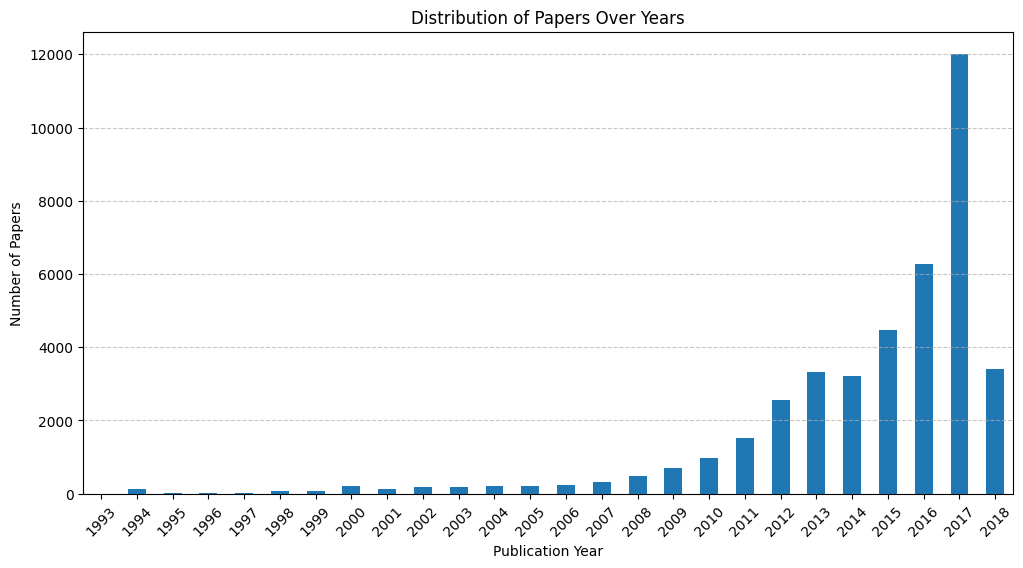

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df["year"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Publication Year")
plt.ylabel("Number of Papers")
plt.title("Distribution of Papers Over Years")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


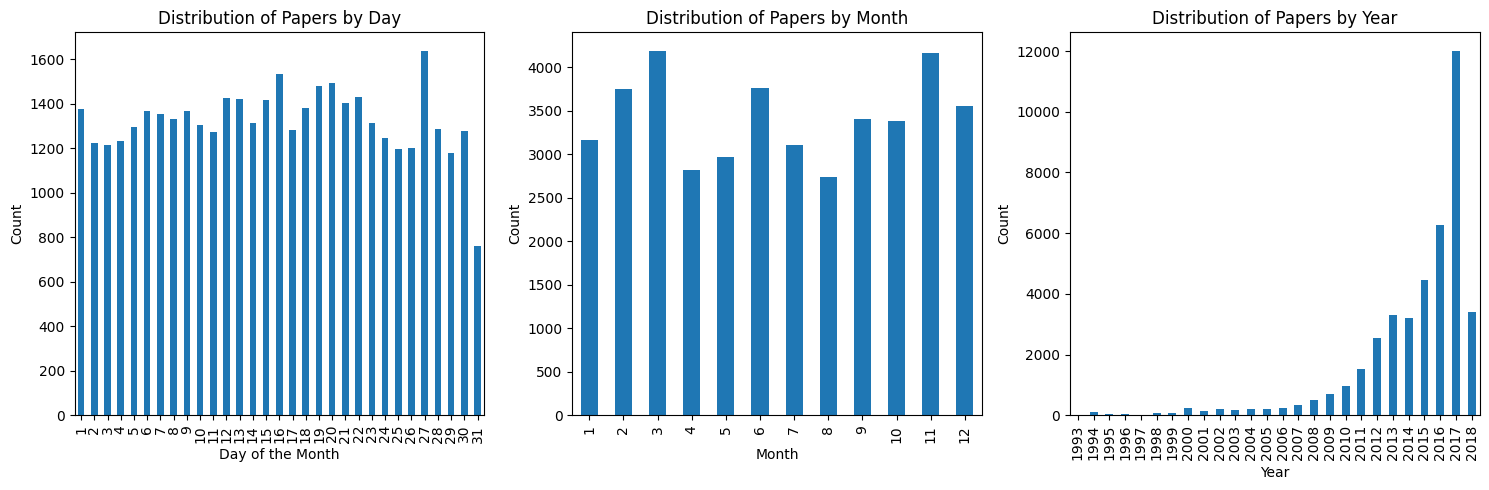

In [17]:
# Set figure size
plt.figure(figsize=(15, 5))

# Plot `day` distribution
plt.subplot(1, 3, 1)
df["day"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Day of the Month")
plt.ylabel("Count")
plt.title("Distribution of Papers by Day")

# Plot `month` distribution
plt.subplot(1, 3, 2)
df["month"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Distribution of Papers by Month")

# Plot `year` distribution
plt.subplot(1, 3, 3)
df["year"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Distribution of Papers by Year")


plt.tight_layout()
plt.show()


Plot a bar plot of the most-reocurring tag terms (for example, *cs.AI*). Articles may have multiple tag terms, so make sure to parse the data correctly.

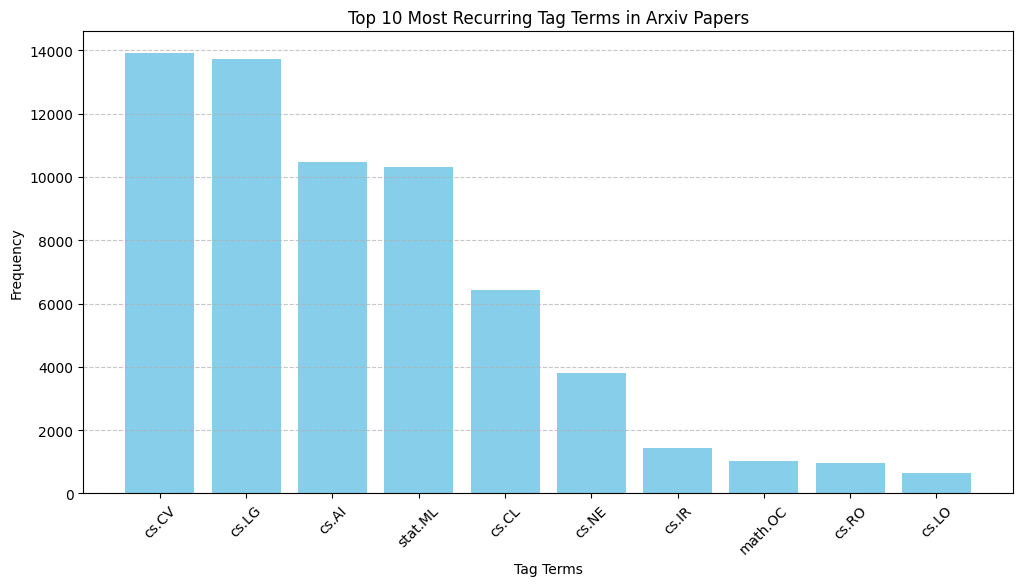

In [19]:
from collections import Counter
import ast

# Ensure 'tag' is properly formatted
df["tag"] = df["tag"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Extract all tag terms from the dataset
all_tags = []
for tags in df["tag"]:
    if isinstance(tags, list):  # Ensure it's a list before iterating
        all_tags.extend([tag["term"] for tag in tags if isinstance(tag, dict) and "term" in tag])

# Count occurrences of each tag
tag_counts = Counter(all_tags)

# Convert to DataFrame and sort by frequency
tag_df = pd.DataFrame(tag_counts.items(), columns=["Tag", "Count"]).sort_values(by="Count", ascending=False)

# Select top 10 most common tags
top_tags = tag_df.head(10)

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_tags["Tag"], top_tags["Count"], color="skyblue")

# Labels and title
plt.xlabel("Tag Terms")
plt.ylabel("Frequency")
plt.title("Top 10 Most Recurring Tag Terms in Arxiv Papers")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


Now, normalize this plot to the total number of articles in each year.

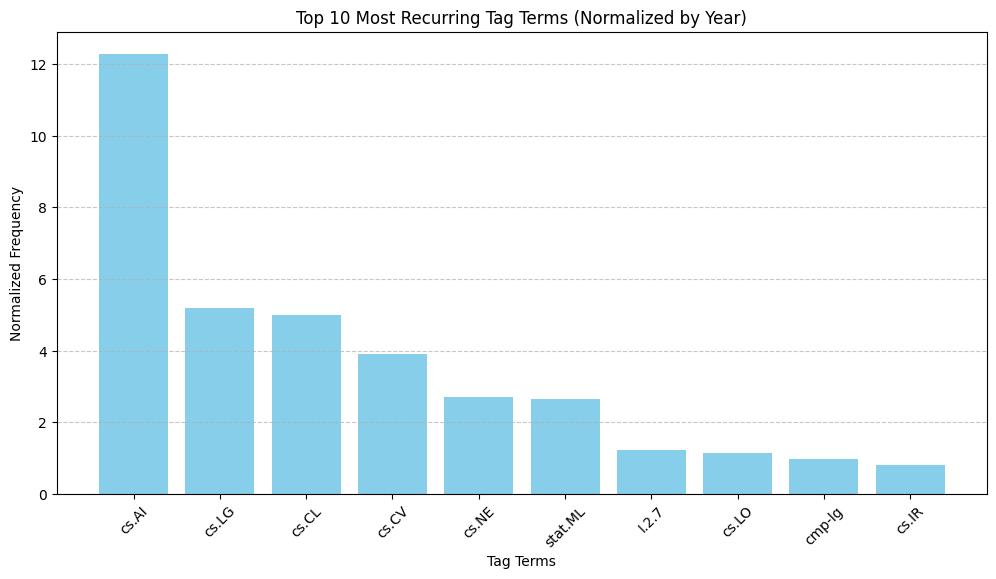

In [20]:
# Extract all tags and associate them with the publication year
tag_year_counts = {}

for index, row in df.iterrows():
    year = row["year"]
    tags = row["tag"]
    
    if isinstance(tags, list):  # Ensure it's a list before iterating
        for tag in tags:
            if isinstance(tag, dict) and "term" in tag:
                tag_term = tag["term"]
                
                if year not in tag_year_counts:
                    tag_year_counts[year] = Counter()
                
                tag_year_counts[year][tag_term] += 1

# Calculate total number of papers per year
year_counts = df["year"].value_counts().to_dict()

# Normalize tag frequencies per year
normalized_tag_counts = Counter()
for year, tags in tag_year_counts.items():
    total_papers = year_counts.get(year, 1)  # Avoid division by zero
    for tag, count in tags.items():
        normalized_tag_counts[tag] += count / total_papers  # Normalize

# Convert to DataFrame and sort by frequency
tag_df = pd.DataFrame(normalized_tag_counts.items(), columns=["Tag", "Normalized Frequency"])
tag_df = tag_df.sort_values(by="Normalized Frequency", ascending=False)

# Select top 10 most common tags (normalized)
top_tags = tag_df.head(10)

# Plot normalized bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_tags["Tag"], top_tags["Normalized Frequency"], color="skyblue")

# Labels and title
plt.xlabel("Tag Terms")
plt.ylabel("Normalized Frequency")
plt.title("Top 10 Most Recurring Tag Terms (Normalized by Year)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


## Section 2: NLP

### 2.1 POS Tagging

Perform POS tagging for 10 samples of `summary` values. You may use libraries such as `spaCy` for POS tagging. Print the POS tagged summaries.

In [24]:
pip install spacy
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 217.9 kB/s eta 0:00:59
     --------------------------------------- 0.0/12.8 MB 245.8 kB/s eta 0:00:52
     --------------------------------------- 0.1/12.8 MB 438.1 kB/s eta 0:00:30
     --------------------------------------- 0.1/12.8 MB 467.6 kB/s eta 0:00:28
      -------------------------------------- 0.2/12.8 MB 811.5 kB/s eta 0:00:16
      -------------------------------------- 0.3/12.8 MB 811.7 kB/s eta 0:00:16
     - -------------------------------------- 0.5/12.8 MB 1.3 MB/s eta 0:00:10
     - -------------------------------------- 0.6/12.8 MB 1.5 MB/s eta 0:00:09
     --- ------------------------------------ 1.0/12.8 MB 2.1 MB/s eta 0:00:06
     ---- ----------------------------------- 1.3/12.8 MB 2.5


[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import spacy

nlp = spacy.load("en_core_web_sm")

# Select 10 random samples from the "summary" column
sample_summaries = df["summary"].dropna().sample(10, random_state=42).tolist()

# Perform POS tagging and print results
for i, summary in enumerate(sample_summaries):
    doc = nlp(summary)  # Process text with spaCy
    print(f"\n🔹 POS Tagging for Summary {i+1}:\n")
    for token in doc:
        print(f"{token.text} → {token.pos_}")


🔹 POS Tagging for Summary 1:

In → ADP
many → ADJ
physical → ADJ
, → PUNCT
statistical → ADJ
, → PUNCT
biological → ADJ
and → CCONJ
other → ADJ
investigations → NOUN
it → PRON
is → AUX

 → SPACE
desirable → ADJ
to → PART
approximate → VERB
a → DET
system → NOUN
of → ADP
points → NOUN
by → ADP
objects → NOUN
of → ADP
lower → ADJ
dimension → NOUN

 → SPACE
and/or → CCONJ
complexity → NOUN
. → PUNCT
For → ADP
this → DET
purpose → NOUN
, → PUNCT
Karl → PROPN
Pearson → PROPN
invented → VERB
principal → ADJ
component → NOUN

 → SPACE
analysis → NOUN
in → ADP
1901 → NUM
and → CCONJ
found → VERB
' → PUNCT
lines → NOUN
and → CCONJ
planes → NOUN
of → ADP
closest → ADJ
fit → NOUN
to → ADP
system → NOUN
of → ADP

 → SPACE
points → NOUN
' → PUNCT
. → PUNCT
The → DET
famous → ADJ
k → NOUN
- → PUNCT
means → NOUN
algorithm → PROPN
solves → VERB
the → DET
approximation → NOUN
problem → NOUN
too → ADV
, → PUNCT
but → CCONJ

 → SPACE
by → ADP
finite → ADJ
sets → NOUN
instead → ADV
of → ADP
lines → NOUN


Plot a histogram of the part of speechs for these 10 samples.

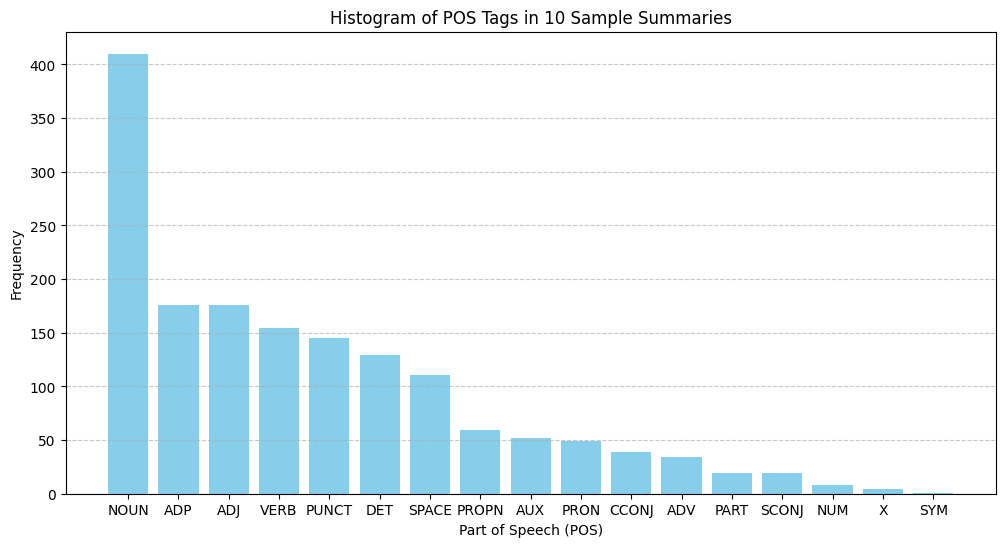

In [26]:
# Perform POS tagging and count occurrences
pos_counts = Counter()

for summary in sample_summaries:
    doc = nlp(summary) 
    pos_counts.update([token.pos_ for token in doc])  

# Convert to sorted lists for plotting
pos_labels, pos_values = zip(*pos_counts.most_common())

# Plot histogram
plt.figure(figsize=(12, 6))
plt.bar(pos_labels, pos_values, color="skyblue")

# Labels and title
plt.xlabel("Part of Speech (POS)")
plt.ylabel("Frequency")
plt.title("Histogram of POS Tags in 10 Sample Summaries")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


### 2.2 NER

Perform Name-Entity Recognition for **all** samples of the `summary` data. Try to use `nlp.pipe` so as to only perform NER, as performing `nlp` as a whole on the whole dataset may take too long.

In [33]:
import spacy
import pandas as pd
from IPython.display import display  # For showing results in Jupyter

# Load spaCy model (disabling unnecessary components for speed)
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser"])  # Only use NER

# Get all summaries (drop NaN values)
summaries = df["summary"].dropna().tolist()

# Use `nlp.pipe()` for efficient batch processing
ner_results = []
for doc in nlp.pipe(summaries, batch_size=50, n_process=1):  # Multi-processing for speed
    entities = [(ent.text, ent.label_) for ent in doc.ents]  # Extract named entities
    ner_results.append(entities)

# Store results in a new column
df["named_entities"] = ner_results

# Display the first 20 rows with named entities
display(df[["summary", "named_entities"]].head(20))


C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\spacy\pipeline\lemmatizer.py:211: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


,summary,named_entities
0,We propose an architecture for VQA which utili...,"[(VQA, ORG), (first, ORDINAL), (VQA, ORG), (1...."
1,Recent approaches based on artificial neural n...,"[(ANN, ORG), (three, CARDINAL)]"
2,We introduce the multiresolution recurrent neu...,"[(two, CARDINAL), (two, CARDINAL), (Ubuntu, PE..."
3,Multi-task learning is motivated by the observ...,"[(Natural Language Processing, ORG), (NLP, ORG..."
4,We present MILABOT: a deep reinforcement learn...,[(the\nMontreal Institute for Learning Algorit...
5,We propose a new generative model of sentences...,"[(first, ORDINAL), (first, ORDINAL)]"
6,We present MILABOT: a deep reinforcement learn...,[(the\nMontreal Institute for Learning Algorit...
7,The paper introduces a new method for discrimi...,"[(1, CARDINAL), (two, CARDINAL), (Cyrillic, GP..."
8,Together with the development of more accurate...,"[(Computer Vision, ORG), (two, CARDINAL), (VQA..."
9,Transforming a graphical user interface screen...,"[(77%, PERCENT), (three, CARDINAL), (Android, ..."


Get all the NER tag types (such `ORDINAL`, `CARDINAL`, etc). Plot a bar chart of it.

C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\spacy\pipeline\lemmatizer.py:211: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


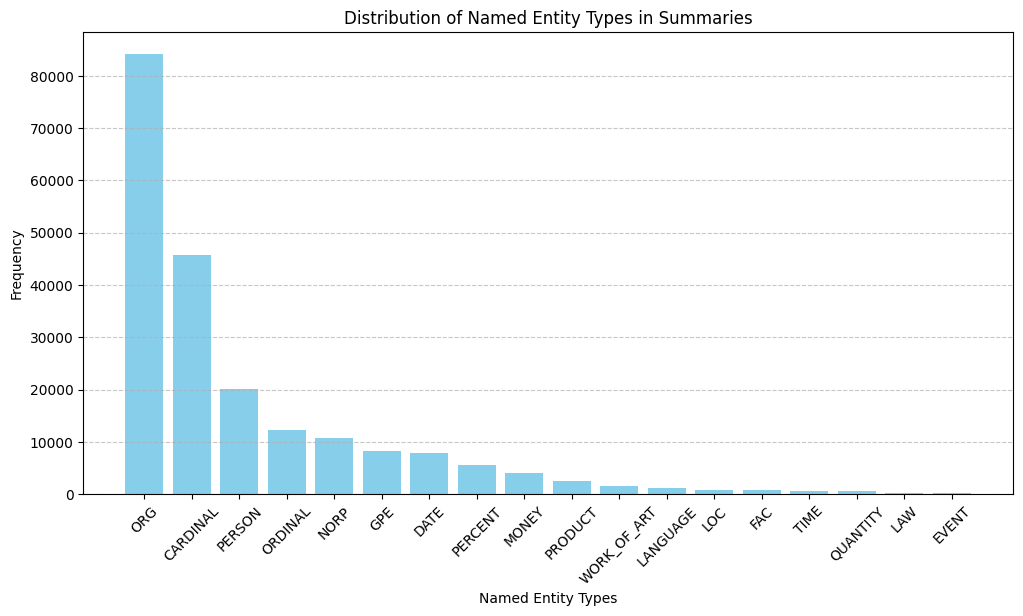

In [34]:
import matplotlib.pyplot as plt
from collections import Counter
import spacy

# Load spaCy model (NER only)
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser"])

# Get all summaries (drop NaN values)
summaries = df["summary"].dropna().tolist()

# Use `nlp.pipe()` for efficient batch processing
ner_tag_counts = Counter()

for doc in nlp.pipe(summaries, batch_size=50, n_process=1):  # Multi-processing for speed
    ner_tag_counts.update([ent.label_ for ent in doc.ents])  # Count entity types

# Convert to a DataFrame for sorting
ner_df = pd.DataFrame(ner_tag_counts.items(), columns=["NER Tag", "Count"]).sort_values(by="Count", ascending=False)

# Plot bar chart of NER tags
plt.figure(figsize=(12, 6))
plt.bar(ner_df["NER Tag"], ner_df["Count"], color="skyblue")

# Labels and title
plt.xlabel("Named Entity Types")
plt.ylabel("Frequency")
plt.title("Distribution of Named Entity Types in Summaries")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


Find all the unique tag types. Plot the top 10 most frequent names for each NER tag type.

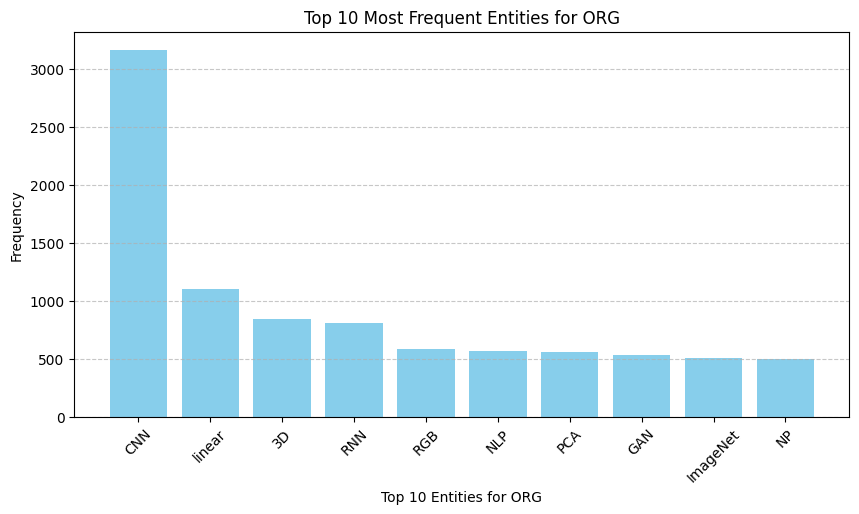

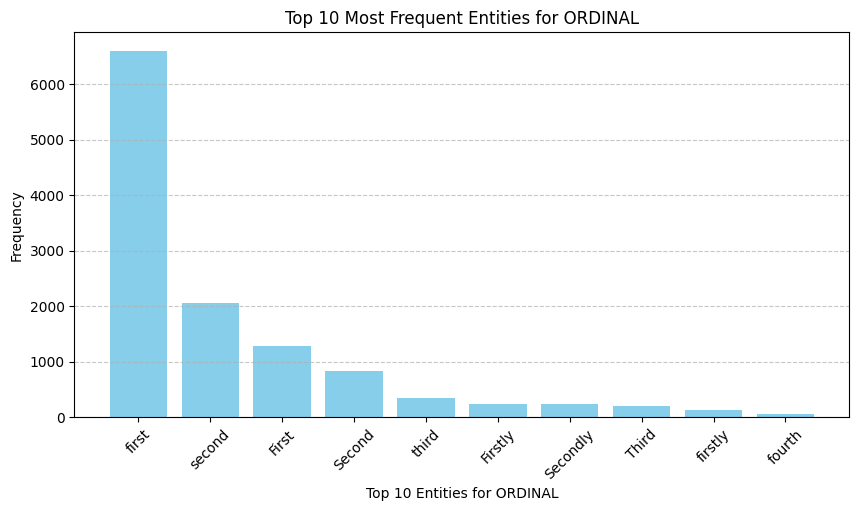

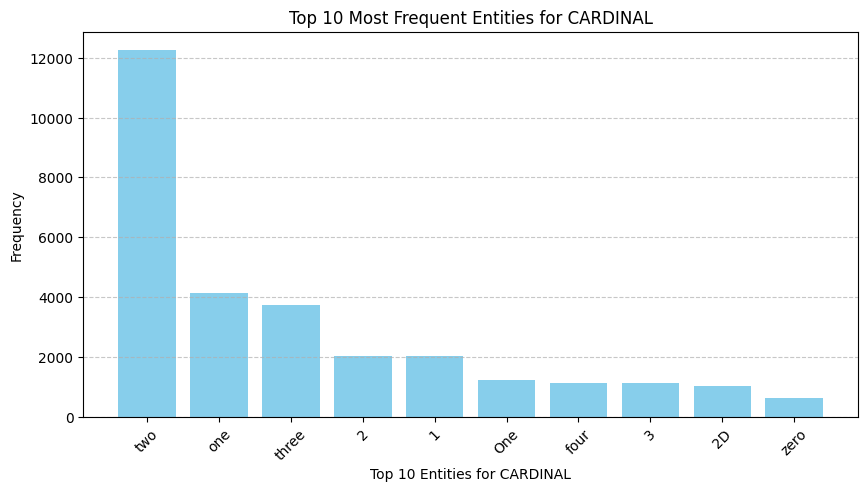

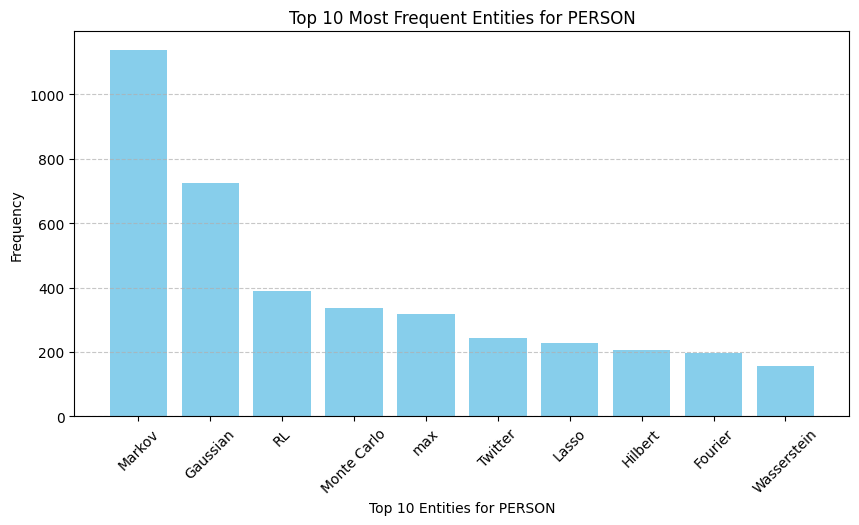

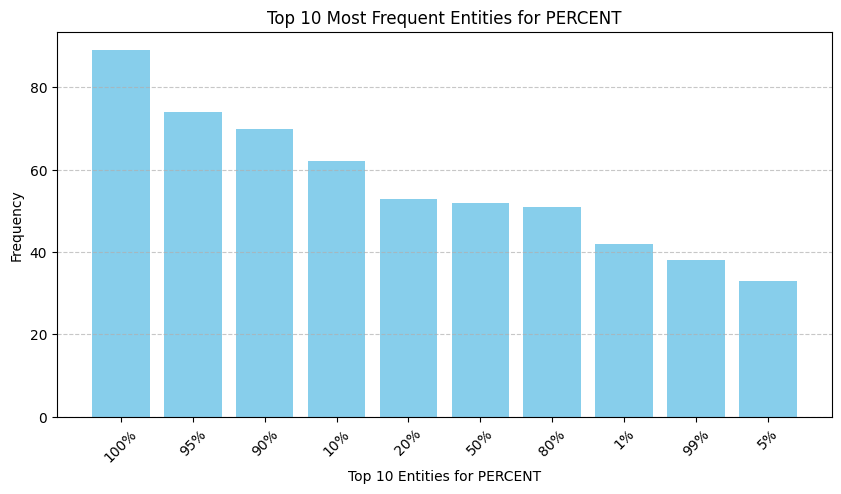

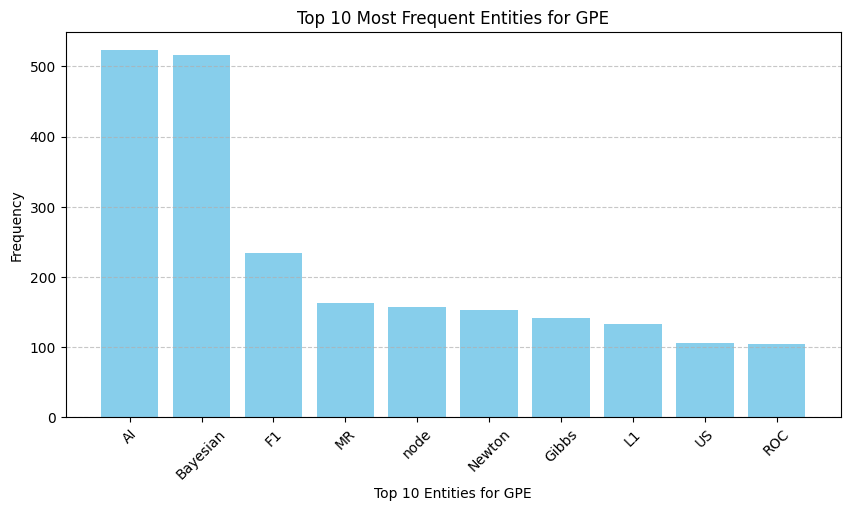

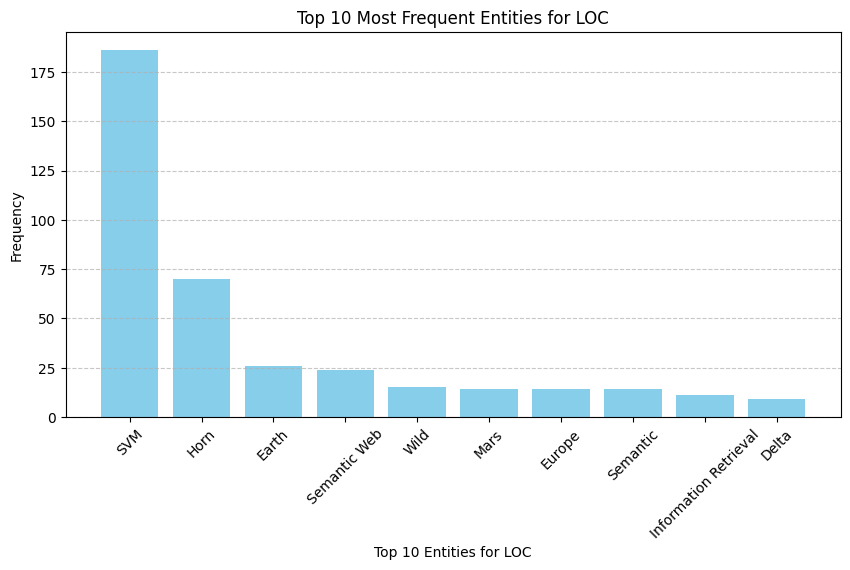

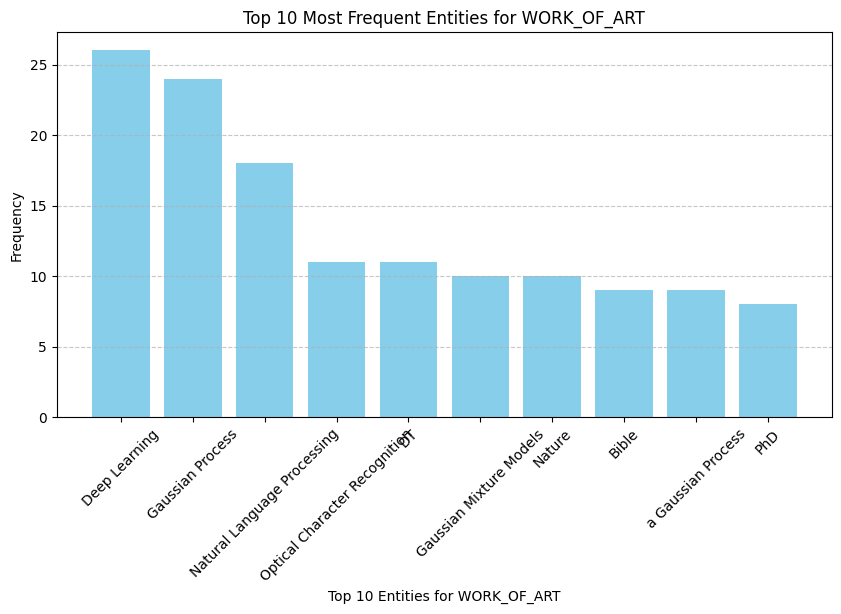

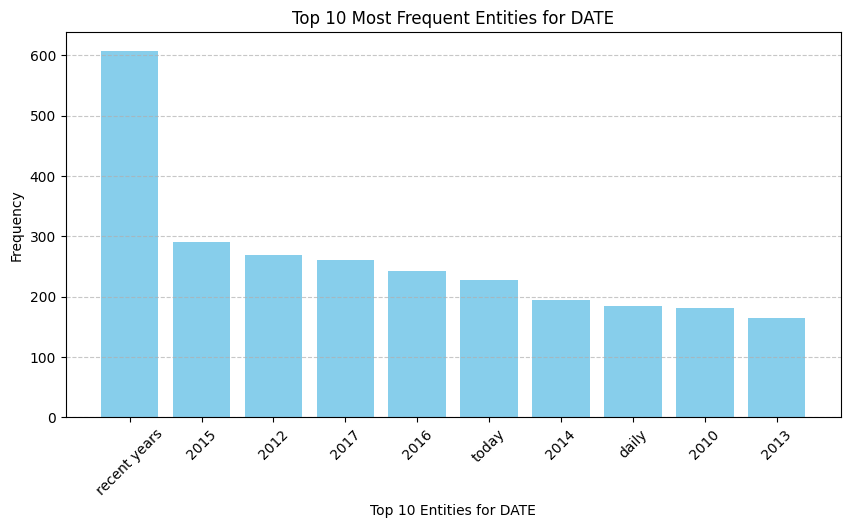

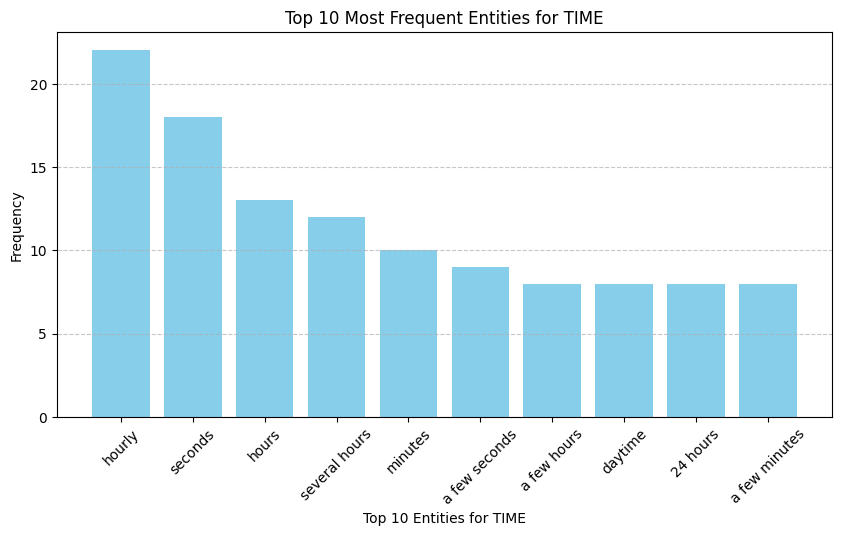

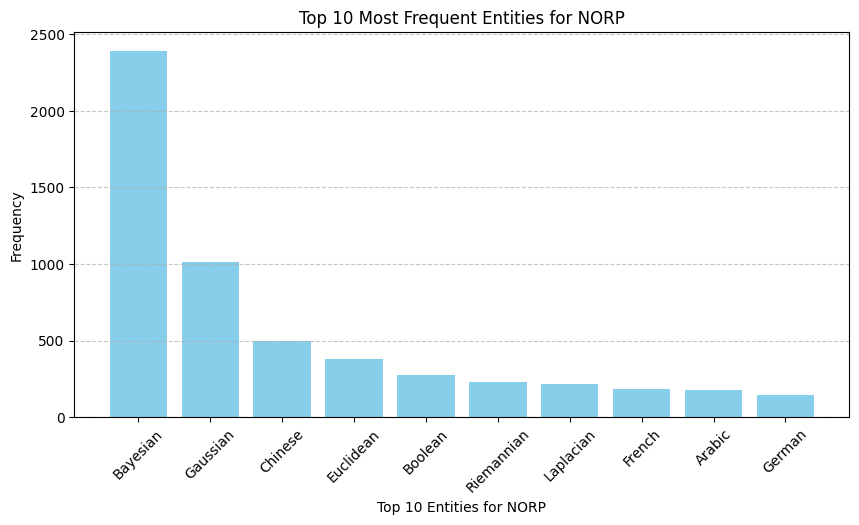

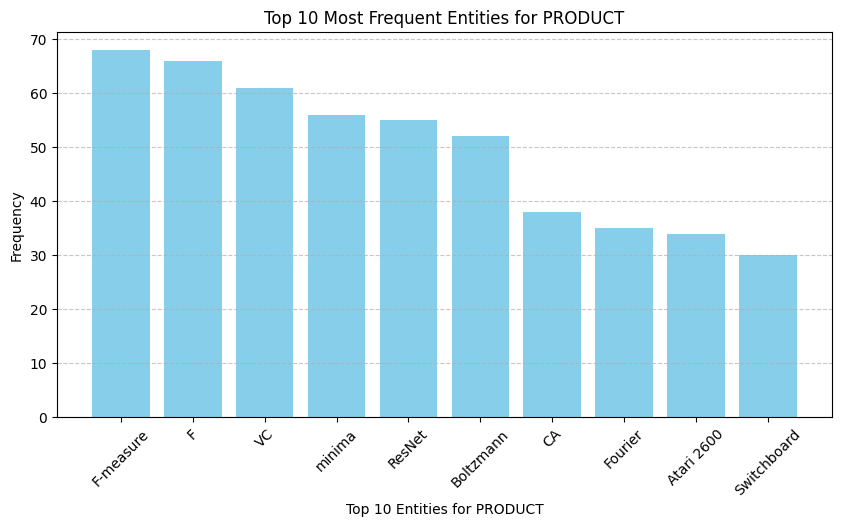

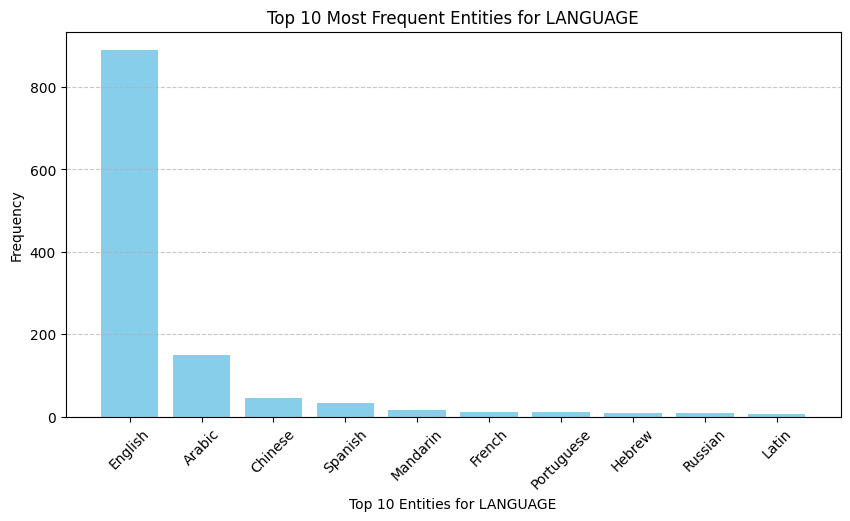

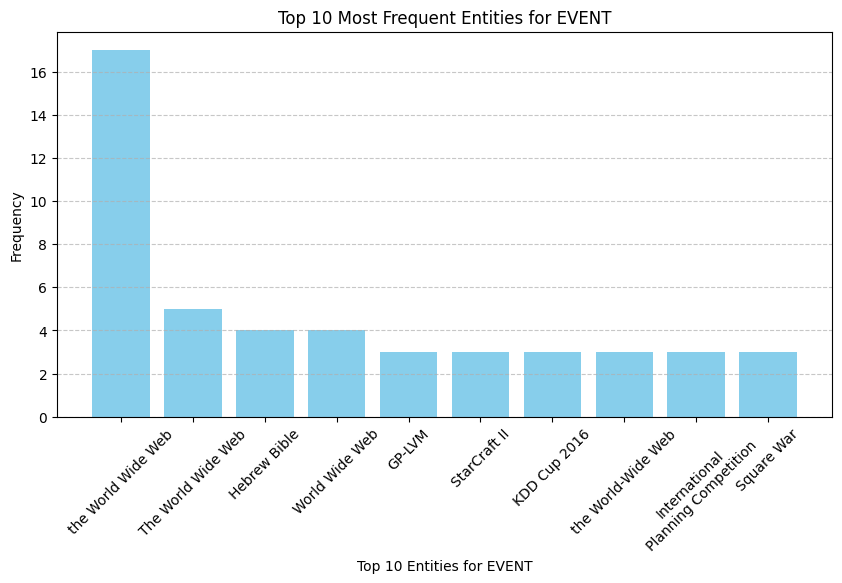

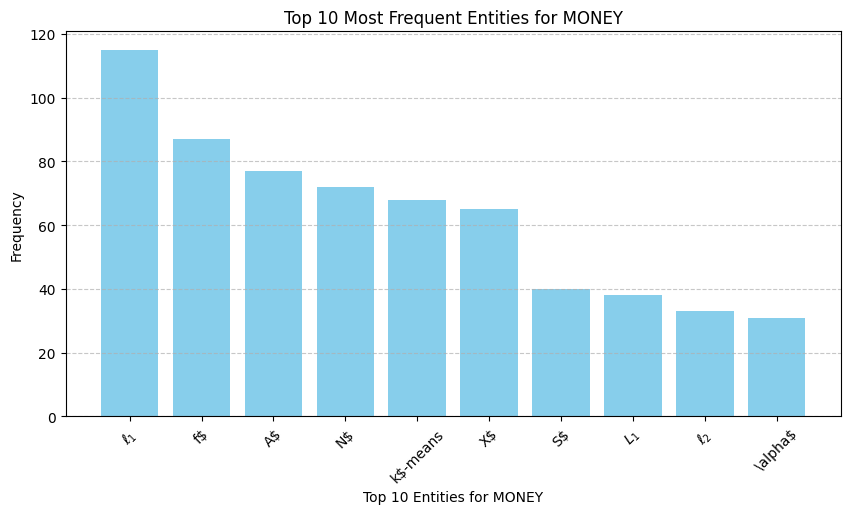

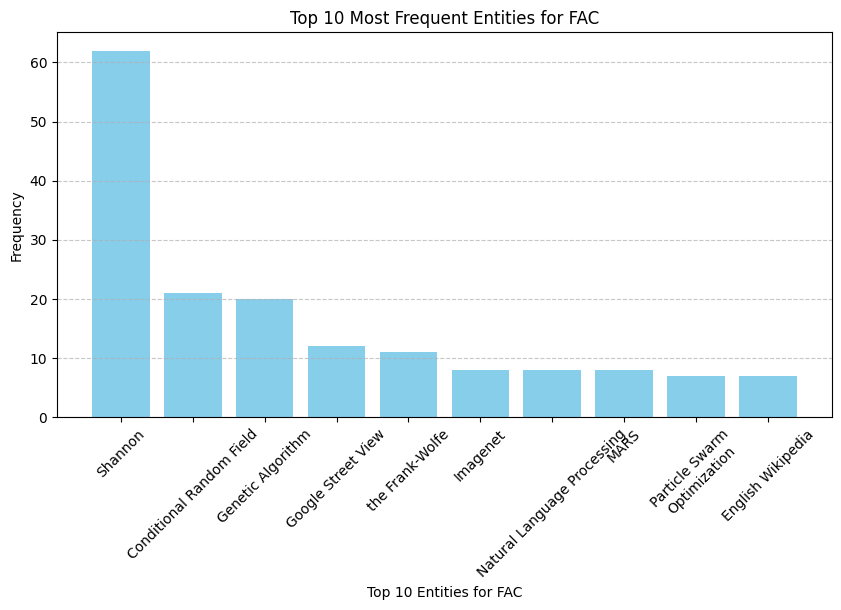

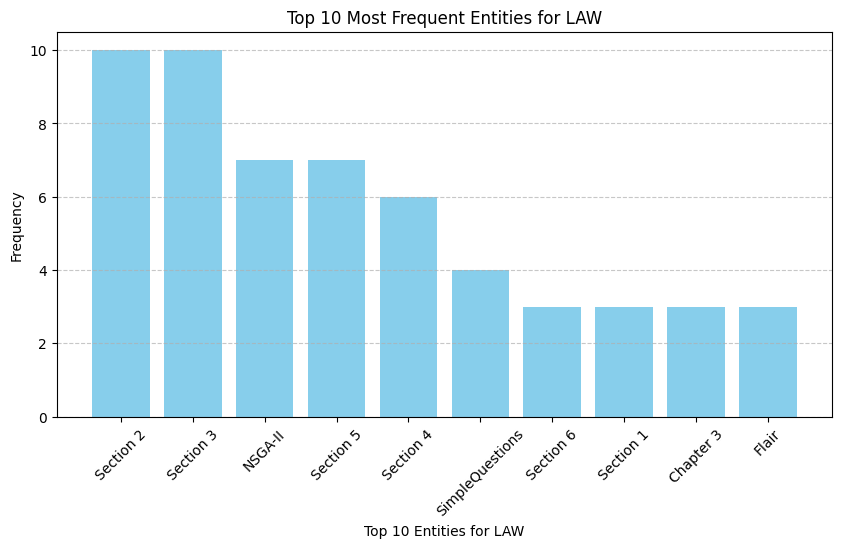

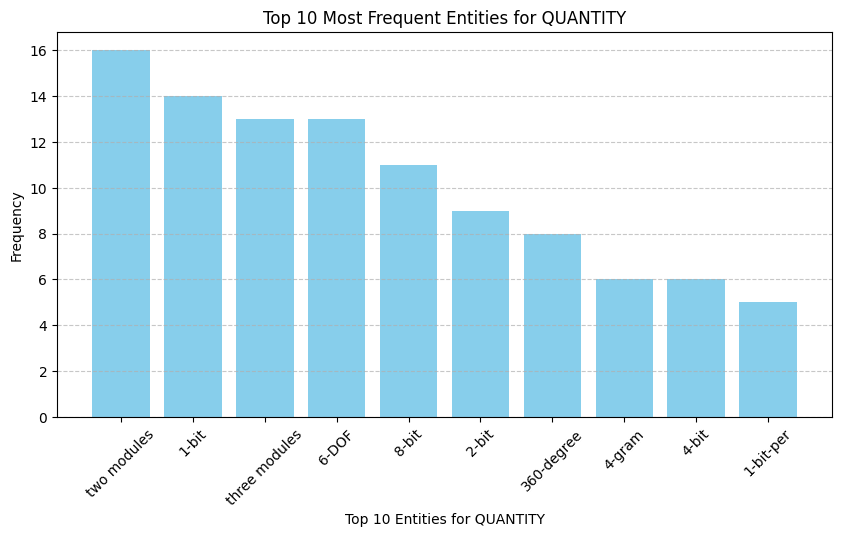

Unique NER Tag Types Found: ['ORG', 'ORDINAL', 'CARDINAL', 'PERSON', 'PERCENT', 'GPE', 'LOC', 'WORK_OF_ART', 'DATE', 'TIME', 'NORP', 'PRODUCT', 'LANGUAGE', 'EVENT', 'MONEY', 'FAC', 'LAW', 'QUANTITY']


In [35]:
import spacy
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Load spaCy model (NER only)
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser"])

# Get all summaries (drop NaN values)
summaries = df["summary"].dropna().tolist()

# Dictionary to store entity occurrences
ner_entity_counts = {}

# Process summaries efficiently using `nlp.pipe()`
for doc in nlp.pipe(summaries, batch_size=50, n_process=1):  # Multi-processing for speed
    for ent in doc.ents:
        if ent.label_ not in ner_entity_counts:
            ner_entity_counts[ent.label_] = Counter()
        ner_entity_counts[ent.label_][ent.text] += 1

# Extract unique NER types
unique_ner_types = list(ner_entity_counts.keys())

# Plot top 10 most frequent names for each NER type
for ner_type, entity_counts in ner_entity_counts.items():
    top_entities = entity_counts.most_common(10)  # Get top 10 most frequent entities
    
    # Convert to DataFrame
    entity_df = pd.DataFrame(top_entities, columns=["Entity", "Count"])
    
    # Plot bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(entity_df["Entity"], entity_df["Count"], color="skyblue")
    
    # Labels and title
    plt.xlabel(f"Top 10 Entities for {ner_type}")
    plt.ylabel("Frequency")
    plt.title(f"Top 10 Most Frequent Entities for {ner_type}")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    
    # Show the plot
    plt.show()

# Print all unique NER tag types
print(f"Unique NER Tag Types Found: {unique_ner_types}")


Based on these observations, how well is the `spaCy` NER tagging performing on this dataset?

Find the top 10 most frequent names in general.

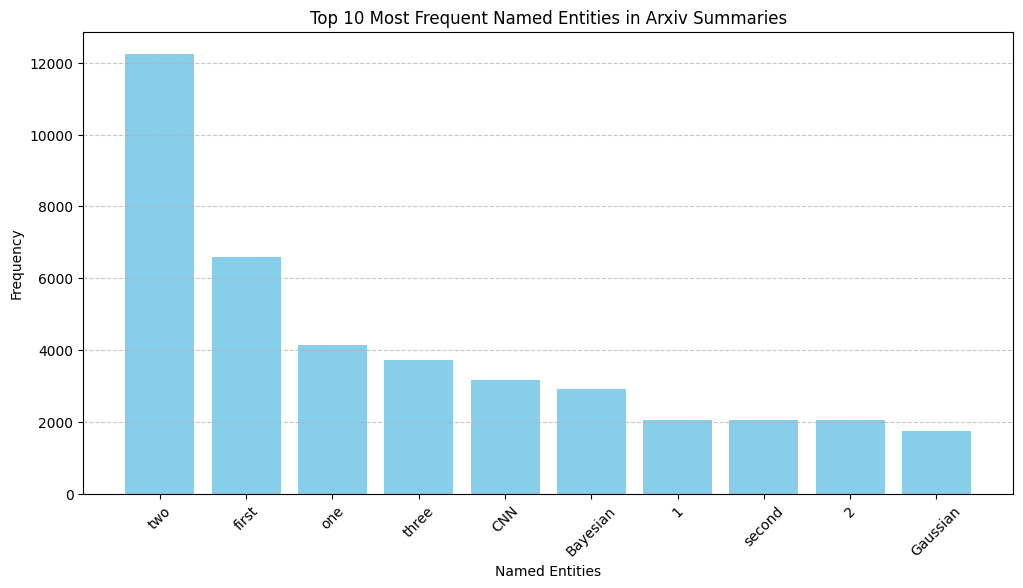

     Entity  Count
0       two  12250
1     first   6606
2       one   4147
3     three   3731
4       CNN   3160
5  Bayesian   2910
6         1   2058
7    second   2054
8         2   2047
9  Gaussian   1749


In [36]:
import spacy
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Load spaCy model (NER only)
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser"])

# Get all summaries (drop NaN values)
summaries = df["summary"].dropna().tolist()

# Counter to store entity frequencies
entity_counts = Counter()

# Process summaries efficiently using `nlp.pipe()`
for doc in nlp.pipe(summaries, batch_size=50, n_process=1):  # Multi-processing for speed
    entity_counts.update([ent.text for ent in doc.ents])  # Count all named entities

# Get the top 10 most frequent entities
top_entities = entity_counts.most_common(10)

# Convert to DataFrame
entity_df = pd.DataFrame(top_entities, columns=["Entity", "Count"])

# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(entity_df["Entity"], entity_df["Count"], color="skyblue")

# Labels and title
plt.xlabel("Named Entities")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Named Entities in Arxiv Summaries")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

# Print the top 10 most frequent entities
print(entity_df)


### 2.3 Embeddings

#### BoW
Use BoW (`sklearn.feature_extraction.text.CountVectorizer`) on `summary` to train a regression model, and choose `year` to be your label. What type of transformation will you choose for changing `year` to be a meaningful label?


Before training your model, you should do some pre-processing, in an attempt to extract useful features from the text. First, use `nltk` to remove the stopwords, and remove all the punctuations. Then use lemmatization on the text to convert them to their base forms.

You are allowed to use a subset of the data.

In [37]:
import nltk
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary resources for nltk
nltk.download("stopwords")
nltk.download("wordnet")

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Function to preprocess text
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = "".join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Tokenize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]  # Lemmatization & Stopword removal
    return " ".join(words)  # Join words back to string

# Apply preprocessing to `summary` column
df["cleaned_summary"] = df["summary"].dropna().apply(preprocess_text)

# Use a subset of data for faster training (optional)
df_sample = df[["cleaned_summary", "year"]].dropna().sample(5000, random_state=42)  # Use 5000 samples for efficiency

# Transform `year` using MinMaxScaler to normalize it
scaler = MinMaxScaler()
df_sample["normalized_year"] = scaler.fit_transform(df_sample["year"].values.reshape(-1, 1))

# Convert text to Bag of Words representation using CountVectorizer
vectorizer = CountVectorizer(max_features=5000)  # Limit to 5000 most frequent words
X = vectorizer.fit_transform(df_sample["cleaned_summary"])

# Define labels (normalized year)
y = df_sample["normalized_year"]

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a regression model (Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate model performance
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

# Print results
print(f"Train R² Score: {train_score:.4f}")
print(f"Test R² Score: {test_score:.4f}")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Train R² Score: 1.0000
Test R² Score: -7.5770


Now, train an appropriate regression model on this data. Report the test set (X and y), and the estimation of your model together. Report the RMSE of the model too.

In [ ]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Function to preprocess text
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = "".join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Tokenize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]  # Lemmatization & Stopword removal
    return " ".join(words)  # Join words back to string

# Apply preprocessing to `summary` column
df["cleaned_summary"] = df["summary"].dropna().apply(preprocess_text)

# Use a subset of data for faster training (optional)
df_sample = df[["cleaned_summary", "year"]].dropna().sample(5000, random_state=42)  # Use 5000 samples for efficiency

# Transform `year` using MinMaxScaler to normalize it
scaler = MinMaxScaler()
df_sample["normalized_year"] = scaler.fit_transform(df_sample["year"].values.reshape(-1, 1))

# Convert text to Bag of Words representation using CountVectorizer
vectorizer = CountVectorizer(max_features=5000)  # Limit to 5000 most frequent words
X = vectorizer.fit_transform(df_sample["cleaned_summary"])

# Define labels (normalized year)
y = df_sample["normalized_year"]

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Ridge Regression model (better regularization than Linear Regression)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Convert predictions back to original year scale
y_test_original = scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

# Create a DataFrame to show Test Set (X, y) and Predictions
test_results_df = pd.DataFrame({
    "Actual Year": y_test_original,
    "Predicted Year": y_pred_original
})

# Display the first 20 rows
from IPython.display import display
display(test_results_df.head(20))

# Print RMSE result
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


,Actual Year,Predicted Year
0,2016.0,2017.292839
1,2018.0,2019.200284
2,2016.0,2015.839947
3,2014.0,2015.940550
4,2018.0,2010.794290
5,2012.0,2007.973818
6,2018.0,2029.717938
7,2017.0,2006.834184
8,2014.0,2013.596188
9,2015.0,2010.232186


Root Mean Squared Error (RMSE): 6.30


Does your error make sense in the context of the data?

#### TF-IDF

Repeat the same procedure on your cleaned data on the same model algorithm, but this time use TF-IDF embedding for the training data.

In [42]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# Function to preprocess text
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = "".join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Tokenize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]  # Lemmatization & Stopword removal
    return " ".join(words)  # Join words back to string

# Apply preprocessing to `summary` column
df["cleaned_summary"] = df["summary"].dropna().apply(preprocess_text)

# Use a subset of data for faster training (optional)
df_sample = df[["cleaned_summary", "year"]].dropna().sample(5000, random_state=42)  # Use 5000 samples for efficiency

# Transform `year` using MinMaxScaler to normalize it
scaler = MinMaxScaler()
df_sample["normalized_year"] = scaler.fit_transform(df_sample["year"].values.reshape(-1, 1))

# Convert text to TF-IDF representation
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to 5000 most important words
X = vectorizer.fit_transform(df_sample["cleaned_summary"])

# Define labels (normalized year)
y = df_sample["normalized_year"]

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Ridge Regression model
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Convert predictions back to original year scale
y_test_original = scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

# Create a DataFrame to show Test Set (X, y) and Predictions
test_results_df = pd.DataFrame({
    "Actual Year": y_test_original,
    "Predicted Year": y_pred_original
})

# Display the first 20 rows
from IPython.display import display
display(test_results_df.head(20))

# Print RMSE result
print(f"Root Mean Squared Error (RMSE) using TF-IDF: {rmse:.2f}")


,Actual Year,Predicted Year
0,2016.0,2015.483117
1,2018.0,2016.897444
2,2016.0,2017.638479
3,2014.0,2012.975728
4,2018.0,2014.060676
5,2012.0,2011.609194
6,2018.0,2018.723984
7,2017.0,2016.148390
8,2014.0,2015.322790
9,2015.0,2013.208225


Root Mean Squared Error (RMSE) using TF-IDF: 3.29


Did your error improve? Why?

#### GLoVe

This time use the GloVe embedding to train your model, and repeat the same steps as before.

##### Downloading GloVe:
The original GloVe embeddings come in various dimensions, with the most common ones being 50-dimensional and 100-dimensional. The 50-dimensional version is smaller and requires less memory, making it a good choice if we are working with limited resources. There are multiple options on where to download GloVe:

1. **Stanford NLP Website**: Visit the [GloVe page on Stanford NLP's website](https://nlp.stanford.edu/projects/glove/). Scroll down to the section "Download pre-trained word vectors" and download the glove.6B.zip file.
2. **From Kaggle**: Go to [Kaggle's GloVe 50D dataset](https://www.kaggle.com/datasets/rtatman/glove-global-vectors-for-word-representation) page. Click on the "Download" button to get the file.
3. `torchtext.vocab.GloVe(name="6B", dim=50, max_vectors=20_000)`

In [45]:
pip install nltk scikit-learn torchtext


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
    --------------------------------------- 0.0/1.9 MB 163.8 kB/s eta 0:00:12
    --------------------------------------- 0.0/1.9 MB 163.8 kB/s eta 0:00:12
   - -------------------------------------- 0.1/1.9 MB 286.7 kB/s eta 0:00:07
   - -------------------------------------- 0.1/1.9 MB 286.7 kB/s eta 0:00:07
   -- ------------------------------------- 0.1/1.9 MB 285.2 kB/s eta 0:00:07
   -- ------------------------------------- 0.1/1.9 MB 341.3 kB/s eta 0:00:06
   --- ------------------------------------ 0.2/1.9 MB 351.5 kB/s eta 0:00:06
   ---- ----------------------------------- 0.2/1.9 MB 409.6 kB/s eta 0:00:05
   ---- --------------


[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
pip install --upgrade torch torchvision torchaudio torchtext --index-url https://download.pytorch.org/whl/cpu


Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
      --------------------------------------- 0.0/1.9 MB 262.6 kB/s eta 0:00:08
     - -------------------------------------- 0.1/1.9 MB 550.5 kB/s eta 0:00:04
     - -------------------------------------- 0.1/1.9 MB 416.7 kB/s eta 0:00:05
     --- ------------------------------------ 0.2/1.9 MB 756.6 kB/s eta 0:00:03
     ---- ----------------------------------- 0.2/1.9 MB 734.2 kB/s eta 0:00:03
     ------ --------------------------------- 0.3/1.9 MB 984.6 kB/s eta 0:00:02
     -------- ------------------------------- 0.4/1.9 MB 1.1 MB/s eta 0:00:02
     ---------- ----------------------------- 0.5/1.9 MB 1.1 MB/s eta 0:00:02
     ------------- -------------------------- 0.7/1.9 MB 1.5 MB/s eta 0:00:01
     ----

In [121]:
import numpy as np

# Function to load GloVe embeddings from a file
def load_glove_embeddings(file_path):
    glove_dict = {}
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            glove_dict[word] = vector
    return glove_dict

# ✅ UPDATE THIS PATH to where you saved `glove.6B.50d.txt`
glove_path = "glove.6B.50d.txt"  # Example: "C:/Users/your_name/Downloads/glove.6B.50d.txt"
glove_dict = load_glove_embeddings(glove_path)

# Function to convert text into a GloVe vector (average word vectors)
def text_to_glove_vector(words, glove_dict, embedding_dim=50):
    vectors = [glove_dict[word] for word in words if word in glove_dict]  # Get vectors for words in GloVe
    if vectors:
        return np.mean(vectors, axis=0)  # Average word vectors
    else:
        return np.zeros(embedding_dim)  # Return zero vector if no words match

# ✅ Test loading a word
if "computer" in glove_dict:
    print(glove_dict["computer"])  # Should print a 50-dimensional vector
else:
    print("Word 'computer' not found in GloVe dictionary.")

[ 0.079084 -0.81504   1.7901    0.91653   0.10797  -0.55628  -0.84427
 -1.4951    0.13418   0.63627   0.35146   0.25813  -0.55029   0.51056
  0.37409   0.12092  -1.6166    0.83653   0.14202  -0.52348   0.73453
  0.12207  -0.49079   0.32533   0.45306  -1.585    -0.63848  -1.0053
  0.10454  -0.42984   3.181    -0.62187   0.16819  -1.0139    0.064058
  0.57844  -0.4556    0.73783   0.37203  -0.57722   0.66441   0.055129
  0.037891  1.3275    0.30991   0.50697   1.2357    0.1274   -0.11434
  0.20709 ]


##### Embeddings rich with semantics

It seems that the GloVe embedding captures some of the semantic relationship in its embeddings, and we are going to put that to the test.

Firstly, we define the *cosine similarity* as:

$$
\cos{\theta} = \frac{A\cdot B}{\Vert A \Vert \Vert B \Vert}
$$

Where $A$ and $B$ are vectors. Let $E(W)$ denote the embedding of the word $W$. We want to see if the following relationship holds true:

$$
E(\text{woman})-E(\text{man}) + E(\text{king}) \approx^? E(\text{queen})
$$

For this, find the most similar vector to $[E(\text{woman})-E(\text{man}) + E(\text{king})]$ using the cosine similarity metric in the GloVe corpus, and see if it equals to `queen`.

In [124]:
# Function to compute cosine similarity
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Compute the analogy vector: woman - man + king
if all(word in glove_dict for word in ["woman", "man", "king"]):
    analogy_vector = glove_dict["woman"] - glove_dict["man"] + glove_dict["king"]
else:
    raise ValueError("One or more words not found in GloVe dictionary.")

# Find the most similar word using cosine similarity
max_similarity = -1
best_word = None

for word, vector in glove_dict.items():
    if word not in ["woman", "man", "king"]:  # Exclude input words
        similarity = cosine_similarity(analogy_vector, vector)
        if similarity > max_similarity:
            max_similarity = similarity
            best_word = word

# ✅ Output the closest word found
print(f"Closest word to 'woman - man + king': {best_word}")


Closest word to 'woman - man + king': queen


This shows that the vector $[E(\text{woman})-E(\text{man})]$ captures some semantic information about *femininity*. Now, we want to see what the *feminine* version of the words given to you below is.

For each word given below, find their feminine version using the GloVe embedding.

In [125]:
# Function to compute cosine similarity
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Compute femininity vector: woman - man
if "woman" in glove_dict and "man" in glove_dict:
    femininity_vector = glove_dict["woman"] - glove_dict["man"]
else:
    raise ValueError("Words 'woman' or 'man' not found in GloVe dictionary.")

# ✅ Given words to find their feminine versions
words = [
    "actor", "prince", "king", "waiter", "host",
    "bridegroom", "bachelor", "god", "hero", "emperor",
    "duke", "sir", "father", "uncle", "brother",
    "dog", "bull", "lion", "warrior", "wizard",
    "knight", "hunter", "boy", "son", "grandfather"
]

# Find feminine versions
feminine_versions = {}

for word in words:
    if word in glove_dict:
        transformed_vector = glove_dict[word] + femininity_vector  # Apply transformation
        
        # Find closest word using cosine similarity
        max_similarity = -1
        best_word = None
        
        for other_word, vector in glove_dict.items():
            if other_word not in [word, "woman", "man"]:  # Exclude input words
                similarity = cosine_similarity(transformed_vector, vector)
                if similarity > max_similarity:
                    max_similarity = similarity
                    best_word = other_word
        
        feminine_versions[word] = best_word
    else:
        feminine_versions[word] = "Not found in GloVe"

# ✅ Output the results
for word, feminine_word in feminine_versions.items():
    print(f"The feminine version of '{word}' is: {feminine_word}")


The feminine version of 'actor' is: actress
The feminine version of 'prince' is: princess
The feminine version of 'king' is: queen
The feminine version of 'waiter' is: waitress
The feminine version of 'host' is: hosted
The feminine version of 'bridegroom' is: bride
The feminine version of 'bachelor' is: bachelors
The feminine version of 'god' is: divine
The feminine version of 'hero' is: heroine
The feminine version of 'emperor' is: empress
The feminine version of 'duke' is: duchess
The feminine version of 'sir' is: elizabeth
The feminine version of 'father' is: mother
The feminine version of 'uncle' is: daughter
The feminine version of 'brother' is: daughter
The feminine version of 'dog' is: cat
The feminine version of 'bull' is: horse
The feminine version of 'lion' is: elephant
The feminine version of 'warrior' is: girl
The feminine version of 'wizard' is: girl
The feminine version of 'knight' is: queen
The feminine version of 'hunter' is: sarah
The feminine version of 'boy' is: girl

##### Orthogonality

Now we want to see if seemingly unrelated words that contain unrelated semantic information have embedding vectors that are orthogonal to each other. This means their cosine similarity should be close to zero; meaning that $\theta$ in $\cos{\theta}$ should be close to $90\degree$.

Find the angle $\theta$ between these unrelated pairs of words, given to you below.

In [126]:
# Function to compute cosine similarity
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Function to compute angle in degrees
def compute_angle(vec1, vec2):
    cos_theta = cosine_similarity(vec1, vec2)
    theta_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # Clip to avoid numerical errors
    theta_deg = np.degrees(theta_rad)  # Convert to degrees
    return theta_deg

# ✅ Given pairs of unrelated words
unrelated_pairs = [
    ("apple", "democracy"),
    ("bottle", "philosophy"),
    ("guitar", "justice"),
    ("ocean", "mathematics"),
    ("table", "happiness"),
    ("elephant", "quantum"),
    ("bread", "government"),
    ("television", "ethics"),
    ("car", "freedom"),
    ("flower", "economy")
]

# Compute angles for each pair
angles = {}

for word1, word2 in unrelated_pairs:
    if word1 in glove_dict and word2 in glove_dict:
        angle = compute_angle(glove_dict[word1], glove_dict[word2])
        angles[(word1, word2)] = angle
    else:
        angles[(word1, word2)] = "One or both words not found in GloVe"

# ✅ Output the results
for (word1, word2), angle in angles.items():
    if isinstance(angle, float):
        print(f"Angle between '{word1}' and '{word2}': {angle:.2f}°")
    else:
        print(f"Could not compute angle for '{word1}' and '{word2}' - {angle}")


Could not compute angle for 'apple' and 'democracy' - 80.45158386230469
Could not compute angle for 'bottle' and 'philosophy' - 85.83611297607422
Could not compute angle for 'guitar' and 'justice' - 85.13153839111328
Could not compute angle for 'ocean' and 'mathematics' - 85.05272674560547
Could not compute angle for 'table' and 'happiness' - 74.07567596435547
Could not compute angle for 'elephant' and 'quantum' - 95.6484603881836
Could not compute angle for 'bread' and 'government' - 79.07624816894531
Could not compute angle for 'television' and 'ethics' - 77.45118713378906
Could not compute angle for 'car' and 'freedom' - 76.67645263671875
Could not compute angle for 'flower' and 'economy' - 80.85549926757812


##### Orthogonality and dimensionality

It seems that different semantics try to encode themselves perpendicular to each other. These vectors are not *perfectly* orthogonal, but rather *almost* orthogonal; because perfect orthogonality limits the number of vectors to the number of dimensions $N$. We are interested in seeing how by increasing dimensionality we can help the model capture more semantics, i.e give it more room for *almost* orthogonal vectors.

Generate 10,000 random vectors of dimension 50, and 100 (you may want to use `torch.randn`, you will need it later). You can already see that 10,000 is much larger than the number of dimensions. Calculate the pair-wise cosine similarity for each of them. Then, plot a bar chart of the angle between them in **degrees**.

Generating 10000 random vectors of dimension 50...


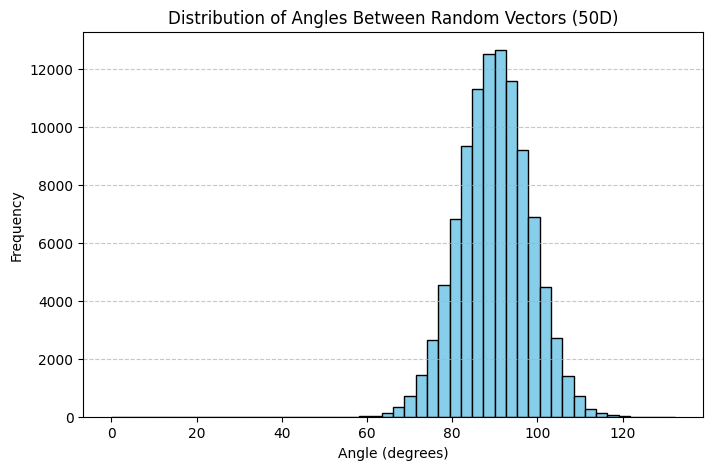

Generating 10000 random vectors of dimension 100...


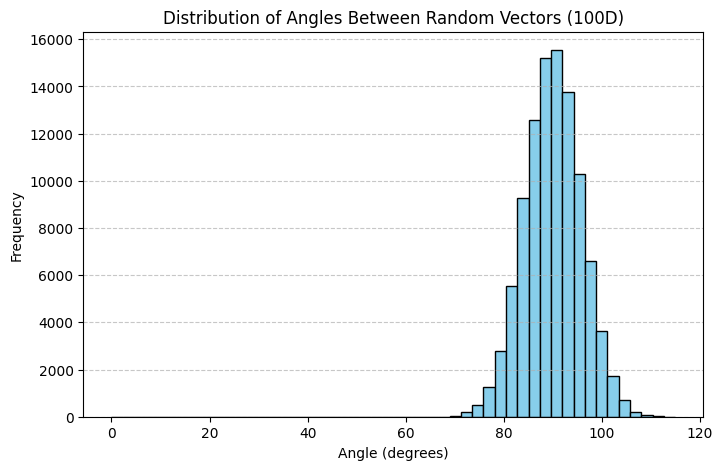

In [128]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Function to compute cosine similarity
def cosine_similarity(vec1, vec2):
    return torch.dot(vec1, vec2) / (torch.norm(vec1) * torch.norm(vec2))

# Function to compute angle from cosine similarity
def compute_angle(vec1, vec2):
    cos_theta = cosine_similarity(vec1, vec2)
    theta_rad = torch.acos(torch.clamp(cos_theta, -1.0, 1.0))  # Clip values to avoid errors
    theta_deg = torch.rad2deg(theta_rad)  # ✅ Fix: Use `torch.rad2deg()` instead of `torch.degrees()`
    return theta_deg.item()

# Function to generate random vectors and compute pairwise angles
def generate_and_plot_angles(dim, num_vectors=10000, num_pairs=100000):
    print(f"Generating {num_vectors} random vectors of dimension {dim}...")
    
    # Generate random vectors
    vectors = torch.randn(num_vectors, dim)  # Each row is a vector in `dim`-dimensional space
    
    # Select random pairs of vectors
    indices = torch.randint(0, num_vectors, (num_pairs, 2))  # Random pairs
    angles = [compute_angle(vectors[i], vectors[j]) for i, j in indices.numpy()]  # ✅ Fix: Convert `indices` to numpy

    # Plot histogram of angles
    plt.figure(figsize=(8, 5))
    plt.hist(angles, bins=50, color="skyblue", edgecolor="black")
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Angles Between Random Vectors ({dim}D)")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# ✅ Generate and plot for 50D
generate_and_plot_angles(dim=50)

# ✅ Generate and plot for 100D
generate_and_plot_angles(dim=100)


Now we intend on making these random vectors more orthogonal to each other. We will write a torch program to achieve this.

1. Normalize the vectors.
2. Set the optimizer and its optimizing target, learning rate, number of epochs, etc.
3. Create a loss function that incentivizes orthogonality. We can begin with the observation that if the matrix of your random vectors is $A$, $AA^T$ is a big matrix of dot products (we choose $AA^T$ instead of $A^TA$ because that is the bigger matrix). Since your vectors are normalized, ideally this matrix should be $I$; therefore a good choice for the loss function is summing over the elements of $AA^T - I$. More specifically, the sum of the *absolute values*. You can add extra motivation by adding the higher powers of $\text{diag}(AA^T - I)$.
4. You might need a cut-off and an activation function for the loss function.
5. Run the optimization. Plot your ending results.
6. Do this for both 50 and 100 dimensions.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Function to optimize random vectors to be more orthogonal
def optimize_orthogonality(dim, num_vectors=1000, epochs=2000, lr=0.01):
    print(f"\nOptimizing {num_vectors} vectors in {dim}D space...")
    
    # Initialize random vectors (requires gradients)
    A = torch.randn(num_vectors, dim, requires_grad=True)

    # Optimizer
    optimizer = torch.optim.Adam([A], lr=lr)

    # Store loss values
    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Normalize vectors
        A_normalized = A / A.norm(dim=1, keepdim=True)
        
        # Compute AA^T (pairwise dot product matrix)
        similarity_matrix = A_normalized @ A_normalized.T  # (num_vectors x num_vectors)
        
        # Identity matrix
        identity_matrix = torch.eye(num_vectors, device=A.device)
        
        # Loss function: sum of absolute values of (AA^T - I)
        loss = torch.sum(torch.abs(similarity_matrix - identity_matrix))
        
        # Additional penalty for diagonal deviations (higher power)
        loss += torch.sum((torch.diag(similarity_matrix - identity_matrix)) ** 4)
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_history.append(loss.item())

        # Print progress every 500 epochs
        if epoch % 500 == 0:
            print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.6f}")

    # Plot loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, label="Loss", color="blue")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve for {num_vectors} Vectors in {dim}D")
    plt.legend()
    plt.grid()
    plt.show()

    return A.detach()

# ✅ Run for 50D
optimized_vectors_50D = optimize_orthogonality(dim=50, num_vectors=1000, epochs=2000, lr=0.01)

# ✅ Run for 100D
optimized_vectors_100D = optimize_orthogonality(dim=100, num_vectors=1000, epochs=2000, lr=0.01)


ModuleNotFoundError: No module named 'torch'

Find how many of these vectors are *almost* orthogonal to every other vector. We define *almost* orthogonal as having a cosine similarity with every other vector in the range $90\degree \pm \epsilon$. Choose $\epsilon = 1\degree$.

## Section 3: Deployment

### AutoML
Use a fitting embedding technique and preprocess your data accordingly. Perform the train/test splitting.

In [1]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load JSON data
file_path = '/content/drive/My Drive/Colab Notebooks/arxivData.json'
data = pd.read_json(file_path)

# Inspect the data structure
print(data.head())
print(data['author'].apply(type).value_counts())


ModuleNotFoundError: No module named 'google.colab'

Now we inted to use `H2O` for AutoML. You may use resources such as Google Colab or Kaggle to circumvent the download sizes. You still need to push your model to DVC, so do it from the remote server.

* Have JRE installed.
* Download H2O from [this link](https://h2o.ai/resources/download/). It is only 764MB.
* `pip install h2o` (this one is 265.8MB)
* Run the following commands to start h2o:
```
cd ~/Downloads
unzip h2o-3.46.0.6.zip
cd h2o-3.46.0.6
java -jar h2o.jar
```

What is the best model that `H2O` comes up with?

In [4]:
pip install -f https://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html h2o


Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
Looking in links: https://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html
     ---------------------------------------- 0.0/265.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/265.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/265.8 MB ? eta -:--:--
     -------------------------------------- 0.0/265.8 MB 245.8 kB/s eta 0:18:02
     -------------------------------------- 0.1/265.8 MB 476.3 kB/s eta 0:09:18
     -------------------------------------- 0.1/265.8 MB 525.1 kB/s eta 0:08:26
     -------------------------------------- 0.2/265.8 MB 811.5 kB/s eta 0:05:28
     -------------------------------------- 0.3/265.8 MB 999.0 kB/s eta 0:04:26
     ---------------------------------------- 0.5/265.8 MB 1.4 MB/s eta 0:03:14
     ---------------------------------------- 0.7/265.8 MB 1.7 MB/s eta 0:02:


[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip



     ------------ -------------------------- 84.8/265.8 MB 1.3 MB/s eta 0:02:25
     ------------ -------------------------- 84.8/265.8 MB 1.3 MB/s eta 0:02:25
     ------------ -------------------------- 84.9/265.8 MB 1.2 MB/s eta 0:02:25
     ------------ -------------------------- 84.9/265.8 MB 1.2 MB/s eta 0:02:25
     ------------ -------------------------- 85.0/265.8 MB 1.2 MB/s eta 0:02:25
     ------------ -------------------------- 85.0/265.8 MB 1.2 MB/s eta 0:02:26
     ------------ -------------------------- 85.1/265.8 MB 1.2 MB/s eta 0:02:26
     ------------ -------------------------- 85.2/265.8 MB 1.2 MB/s eta 0:02:26
     ------------ -------------------------- 85.2/265.8 MB 1.2 MB/s eta 0:02:26
     ------------ -------------------------- 85.3/265.8 MB 1.2 MB/s eta 0:02:26
     ------------ -------------------------- 85.3/265.8 MB 1.2 MB/s eta 0:02:26
     ------------ -------------------------- 85.4/265.8 MB 1.2 MB/s eta 0:02:27
     ------------ ---------------------

In [2]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd
from sklearn.model_selection import train_test_split

# Start H2O cluster
h2o.init()


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 17.0.2+8-LTS-86, mixed mode, sharing)
  Starting server from C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\ASUS\AppData\Local\Temp\tmp27cbdvei
  JVM stdout: C:\Users\ASUS\AppData\Local\Temp\tmp27cbdvei\h2o_ASUS_started_from_python.out
  JVM stderr: C:\Users\ASUS\AppData\Local\Temp\tmp27cbdvei\h2o_ASUS_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,+03:30
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,2 months and 27 days
H2O_cluster_name:,H2O_from_python_ASUS_x01vaw
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.926 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [ ]:
json_file_path = "arxivData.json"
df = pd.read_json(json_file_path)

h2o_df = h2o.H2OFrame(df)

# Define target and features
target = "title" 
features = [col for col in df.columns if col != target]

h2o_df[target] = h2o_df[target].asfactor()

# Train/Test Split
train, test = h2o_df.split_frame(ratios=[0.8], seed=42)

# Run AutoML
aml = H2OAutoML(max_runtime_secs=1200, seed=42)
aml.train(x=features, y=target, training_frame=train)

# Display Best Model
best_model = aml.leader
print("Best Model:", best_model)

# Save the model
model_path = h2o.save_model(model=best_model, path="./h2o_best_model", force=True)
print("Model saved at:", model_path)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
00:39:31.834: AutoML: XGBoost is not available; skipping it.
00:39:32.92: _train param, Dropping bad and constant columns: [link, summary, id]

███████████████████████████████████████████████████████████████ (cancelled) 100%


In [1]:
# Initialize DVC
dvc init

# Track model in DVC
dvc add h2o_best_model
git add h2o_best_model.dvc .gitignore
git commit -m "Add H2O AutoML model"
git push

# Push model to remote storage
dvc remote add origin <remote_storage_url>
dvc push


SyntaxError: invalid syntax (922933989.py, line 2)

### NAS

Use `h2o.estimators.H2ODeepLearningEstimator` for NAS. Show what model H2O comes up with.

In [ ]:
json_file_path = "arxivData.json"
df = pd.read_json(json_file_path)

# Convert to H2OFrame
h2o_df = h2o.H2OFrame(df)

# Define the target column (replace with the actual label column)
target = "label_column"  # Change to the correct column name
features = [col for col in df.columns if col != target]

# ✅ Convert target column to categorical
h2o_df[target] = h2o_df[target].asfactor()

# ✅ Train/Test Split
train, test = h2o_df.split_frame(ratios=[0.8], seed=42)


Push all of your trained models to DVC. Putting the commands in a cell (such as `!dvc init`) makes it easier to read and grade.

In [ ]:
!dvc init
...